In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [14]:
df = pd.read_csv('data/used_cars.csv')

#### Exploratory Data Analysis 

In [15]:
# Number of types of catagories for each variables:
print(df.nunique())

brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64


In [21]:
# data cleaning
# we got rid of engine types, transmission, external color, internal color, clean title, model
print(len(df))
df = df[['model_year', 'milage', 'fuel_type',"accident", "price", "brand"]].dropna()
df_new = df[~df['fuel_type'].isin(["not supported", "–"])].copy(deep=True)
price_raw = df_new['price']
df_new['price'] = np.log(df_new['price'].str.replace(r'[$,]', '', regex=True).astype(float))
df_new['mileage'] = (
    df_new['milage']
    .str.replace(r'[^\d]', '', regex=True)  # keep only digits
    .astype(float)
)

df_new['fuel_type'] = df_new['fuel_type'].astype('category')
df_new['accident'] = df_new['accident'].map({
    'None reported': 0,
    'At least 1 accident or damage reported': 1
})
data_year = 2023
df_new['age'] = data_year - df_new['model_year'].astype(int)

3730


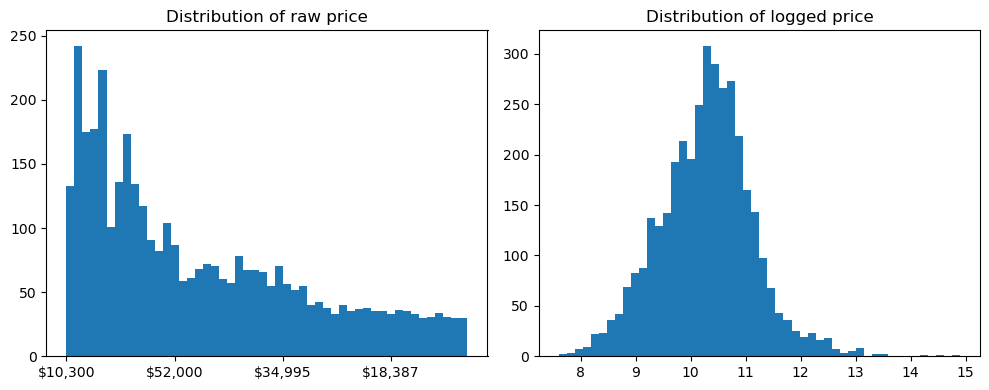

In [27]:
# recover raw price (since you overwrote it)
price_log = df_new['price']

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(price_raw, bins=50)
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(5))  # max 5 ticks
plt.title("Distribution of raw price")

plt.subplot(1,2,2)
plt.hist(price_log, bins=50)
plt.title("Distribution of logged price")

plt.tight_layout()
plt.show()

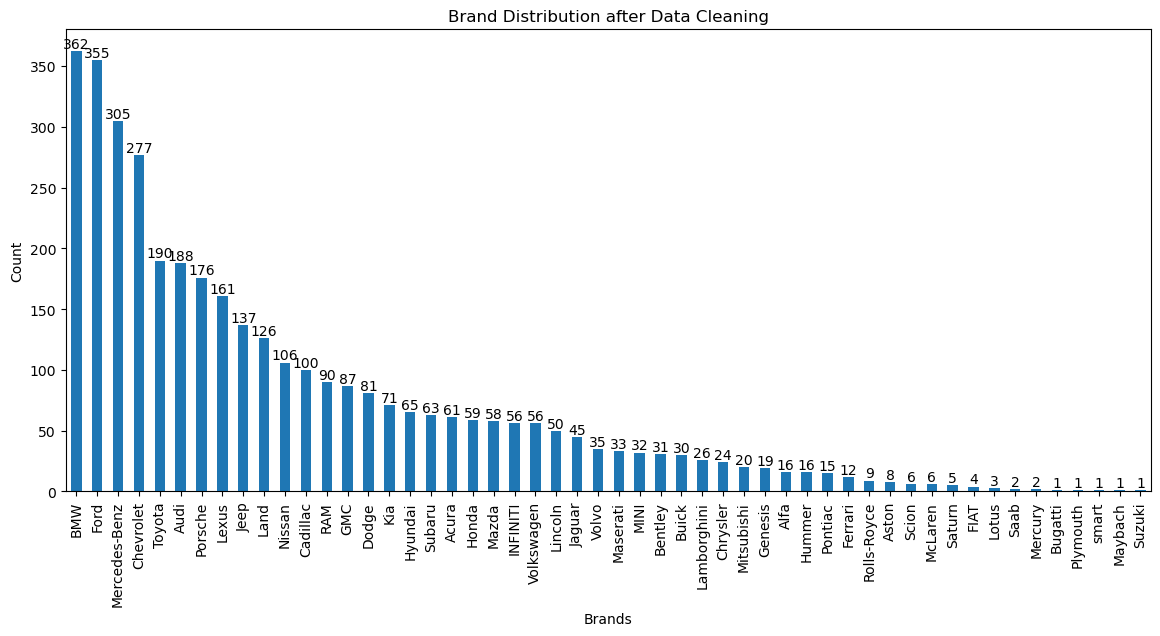

In [17]:
plt.figure(figsize=(14,6))
counts = df_new["brand"].value_counts()

ax = counts.plot(kind='bar')
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Brand Distribution after Data Cleaning')
plt.xlabel('Brands')
plt.ylabel('Count')
plt.show()

In [18]:
df_export = df_new.copy()
df_export = df_export[["mileage", "accident", "fuel_type", "age", "brand", "price"]]
df_export.to_csv("data/cleaned.csv", index=False)

# # Set minimum count required to keep a brand separate
# threshold = 10

# # Count occurrences of each brand
# brand_counts = df_export["brand"].value_counts()

# # Brands meeting threshold
# common_brands = brand_counts[brand_counts >= threshold].index
# # print brands that has little observations:
# non_common_brands = brand_counts[brand_counts < threshold]
# print(non_common_brands)

# # Replace rare brands with "Other"
# df_export["brand"] = df_export["brand"].where(
#     df_export["brand"].isin(common_brands),
#     "Other"
# )
# df_export.to_csv("data/grouped.csv", index=False)

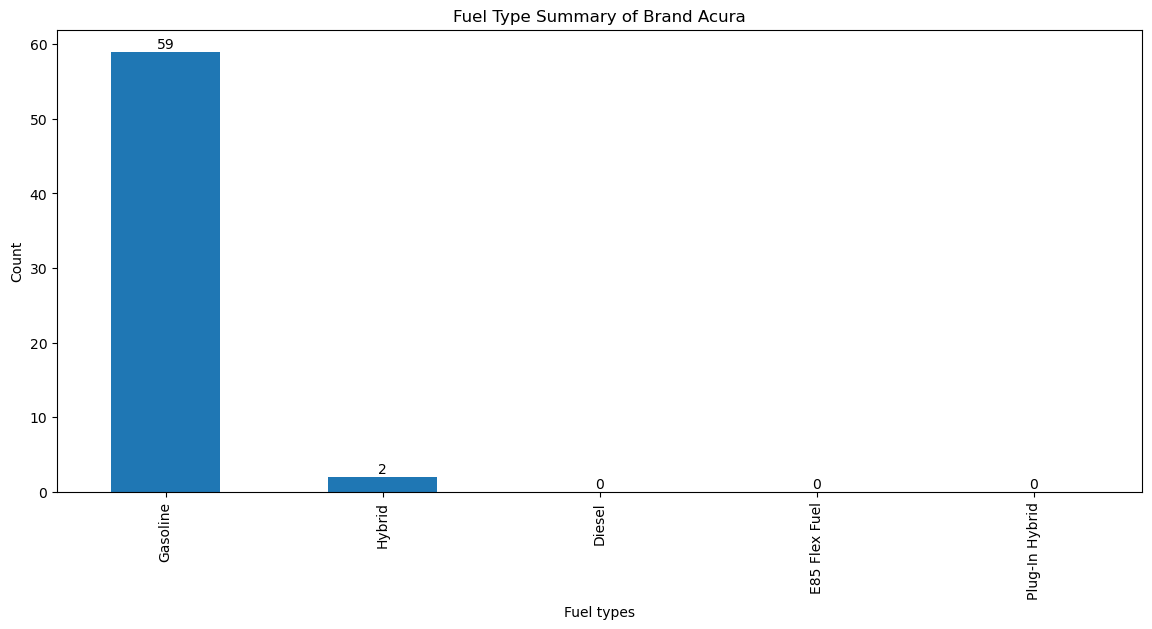

In [19]:
test = df_export[df_export["brand"]=="Acura"]
plt.figure(figsize=(14,6))
counts = test["fuel_type"].value_counts()

ax = counts.plot(kind='bar')
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Fuel Type Summary of Brand Acura')
plt.xlabel('Fuel types')
plt.ylabel('Count')
plt.show()